# Projeto M1.1 — Operações Pontuais e Filtragem Espacial

**Professor:** Felipe Viel

**Integrantes:** Hugo Bertoglio, Fabricio Riccardo, João Guero

---
As imagens vêm do dataset `ImgTrabM1` e devem estar numa pasta `imagens`

## 1. Bibliotecas

In [1]:
import os
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 96

## 2. Funções base

Funções reaproveitadas pelas sete questões: leitura das imagens, conversão ponderada
para tons de cinza, reamostragem, histograma manual, preenchimento de bordas,
convolução 2D e normalização mínimo-máximo. O preenchimento, a convolução e a
normalização seguem as práticas de filtragem espacial vistas em aula.

In [2]:
#Pastas onde as imagens do dataset podem estar
PASTAS_BUSCA = [
    "imagens",
    os.path.join("..", "imagens"),
    os.path.join("trabalho", "imagens"),
    ".",
]

#Leitura e conversao de imagens
def para_cinza(img):
    """Conversao ponderada RGB -> tons de cinza (formula vista em aula).

    O OpenCV so e usado para ler o arquivo do disco. A conversao em si e
    feita na mao, com os pesos 0.299 / 0.587 / 0.114.
    """
    R = img[:, :, 0].astype(float)
    G = img[:, :, 1].astype(float)
    B = img[:, :, 2].astype(float)

    img_grayscale_pondered = 0.299 * R + 0.587 * G + 0.114 * B

    return np.array(img_grayscale_pondered, dtype=np.uint8)

def load_img(nome, grayscale=False):
    """Le uma imagem do dataset procurando nas pastas conhecidas."""
    caminho_encontrado = None
    if os.path.isfile(nome):
        caminho_encontrado = nome
    else:
        for pasta in PASTAS_BUSCA:
            caminho_teste = os.path.join(pasta, nome)
            if os.path.isfile(caminho_teste):
                caminho_encontrado = caminho_teste
                break

    if caminho_encontrado is None:
        raise FileNotFoundError(f"Imagem '{nome}' nao encontrada nas pastas: {PASTAS_BUSCA}")

    img = cv2.imread(caminho_encontrado, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Erro ao abrir a imagem: {caminho_encontrado}")

    #o OpenCV entrega BGR; invertemos a ordem dos canais com o proprio numpy
    img = img[:, :, ::-1]

    if grayscale:
        return para_cinza(img)

    return np.array(img, dtype=np.uint8)

#reamostragem por vizinho mais proximo com numpy (substitui o cv2.resize)
def redimensionar(img, nova_altura, nova_largura):
    altura, largura = img.shape[:2]

    #para cada pixel de saida, qual pixel da entrada lhe corresponde
    linhas = (np.arange(nova_altura) * altura / nova_altura).astype(int)
    colunas = (np.arange(nova_largura) * largura / nova_largura).astype(int)

    linhas[linhas > altura - 1] = altura - 1
    colunas[colunas > largura - 1] = largura - 1

    return img[np.ix_(linhas, colunas)] if img.ndim == 2 else img[np.ix_(linhas, colunas, np.arange(img.shape[2]))]


#histograma

# calcula histograma contando a frequencia de cada tom de 0 a 255
def calcular_histograma(img):
    histogram = np.zeros(256)
    for pixel in img.ravel():
        histogram[pixel] += 1
    return histogram

# plota o histograma com np.linspace e plt.bar
def plotar_histograma(ax, img, titulo, cor="gray"):
    histogram = calcular_histograma(img)

    x = np.linspace(0, 255, 256)
    ax.bar(x, histogram, width=1.0, color=cor)
    ax.set_title(titulo, fontsize=9)
    ax.set_xlabel("intensidade", fontsize=8)
    ax.set_ylabel("frequencia", fontsize=8)
    ax.set_xlim(0, 255)


#exibicao
#mostra imagens lado a lado
def show_images(imagens, titulos, suptitle=None, figsize=None):
    n = len(imagens)
    if figsize is None:
        figsize = (5 * n, 5)

    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    for ax, img, tit in zip(axes, imagens, titulos):
        if img.ndim == 2:
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(img)
        ax.set_title(tit, fontsize=10, pad=6)
        ax.axis("off")

    if suptitle:
        fig.suptitle(suptitle, fontsize=12, y=0.99)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        plt.tight_layout()

    plt.show()

#filtragem espacial
#funcao de padding com zeros
def add_padding(img, padding_height, padding_width):
    n, m = img.shape
    padded_img = np.zeros((n + padding_height * 2, m + padding_width * 2))
    padded_img[padding_height : n + padding_height, padding_width : m + padding_width] = img

    return padded_img

#convolucao 2D com inversao do kernel
def conv2d(img, kernel, padding=True):

    k_height, k_width = kernel.shape
    img_height, img_width = img.shape

    pad_height = k_height // 2
    pad_width = k_width // 2

    if padding:
        padded_img = add_padding(img.astype(float), pad_height, pad_width)
    else:
        padded_img = img.astype(float)

    #inversao da mascara nos dois eixos para convolucao matematica
    kernel_flip = kernel[::-1, ::-1]

    output = np.zeros((img_height, img_width), dtype=float)

    #soma dos produtos entre coeficientes da mascara e pixels correspondentes
    for i_kernel in range(k_height):
        for j_kernel in range(k_width):
            peso = kernel_flip[i_kernel, j_kernel]
            if peso != 0:
                output += peso * padded_img[i_kernel : i_kernel + img_height,
                                            j_kernel : j_kernel + img_width]

    return output

# normalizacao min-max da aula de filtragem espacial
def normalize_minmax(img, new_min=0, new_max=255):
    img_min = img.min()
    img_max = img.max()

    if img_max == img_min:
        return img.copy()

    normalized = (img - img_min) / (img_max - img_min)
    normalized = normalized * (new_max - new_min) + new_min

    return normalized

#limita os valores entre 0 e 255 e converte para uint8
def para_uint8(img):

    img_out = np.array(img, dtype=float)
    img_out[img_out > 255] = 255
    img_out[img_out < 0] = 0
    return np.array(img_out, dtype=np.uint8)

#operacao pontual compartilhada entre as questoes 2 e 4

#alargamento linear de contraste: s = (r - r_min) * (b - a) / (r_max - r_min) + a
def linContrastStretching(im, a, b):
    img_in = im.astype(float)
    r_min = img_in.min()
    r_max = img_in.max()

    #se a imagem for toda de uma cor so, evita divisao por zero
    if r_max == r_min:
        return im.copy()

    img_out = (img_in - r_min) * ((b - a) / (r_max - r_min)) + a

    return para_uint8(img_out)

## Questão 1: Manipulação de Pixels

**a)** Função para determinar a cor (RGB) mais frequente e sua quantidade de ocorrências.
**b)** Função `mergeImage(fg, bg)` para extrair o objeto em primeiro plano (chroma key) e inserir no fundo.
**c)** Aplicação da função em pares distintos de imagens de primeiro plano e fundo.
> Para o chroma key, separamos os canais R, G e B e selecionamos os pixels onde o verde é predominante sobre o vermelho e o azul para substituir pelo fundo.



In [16]:
# 1a)cor que ocorre com maior frequencia na imagem colorida
def cor_mais_frequente(img):
    #cada linha passa a ser um pixel com seus tres canais
    pixels = img.reshape(-1, 3)

    #conta quantas vezes cada combinacao RGB aparece
    cores, contagens = np.unique(pixels, axis=0, return_counts=True)

    #a cor mais frequente e a de maior contagem
    idx_maior = np.argmax(contagens)
    cor = tuple(int(c) for c in cores[idx_maior])
    qtd = int(contagens[idx_maior])

    return cor, qtd

# 1b)mergeImage: chroma key do primeiro plano sobre o plano de fundo
def mergeImage(fg, bg):
    #o fundo precisa ter o mesmo tamanho do primeiro plano
    if fg.shape[:2] != bg.shape[:2]:
        bg = redimensionar(bg, fg.shape[0], fg.shape[1])

    #isolando as bandas com numpy
    R = fg[:, :, 0].astype(float)
    G = fg[:, :, 1].astype(float)
    B = fg[:, :, 2].astype(float)

    #o pixel e de fundo quando o verde e forte e domina os outros dois canais
    mascara_verde = (G > 75) & (G > R * 1.15) & (G > B * 1.15)

    #onde a mascara e verdadeira ficamos com o fundo
    img_out = fg.copy()
    img_out[mascara_verde] = bg[mascara_verde]

    return img_out

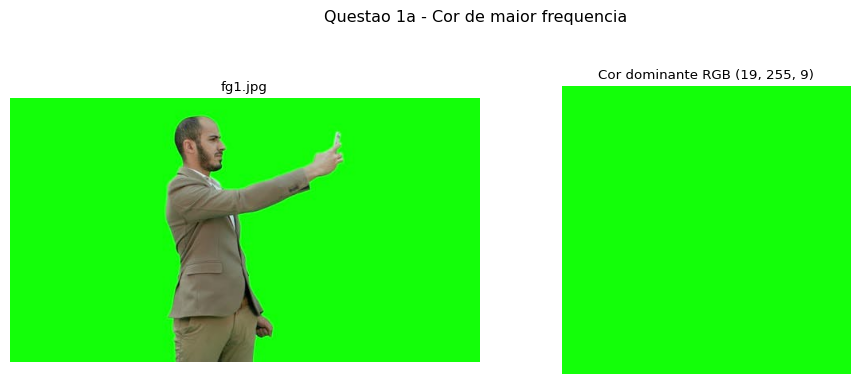

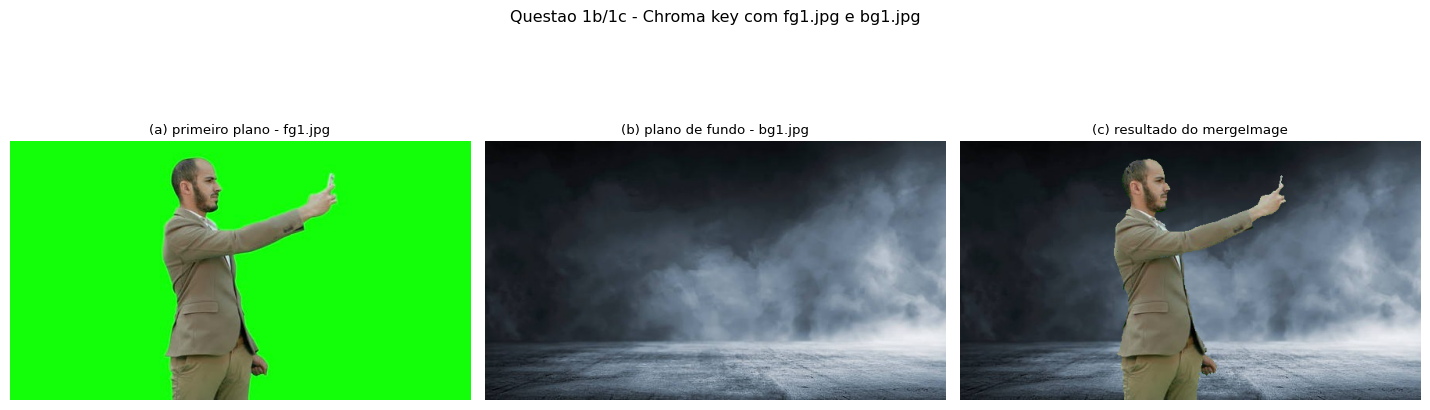

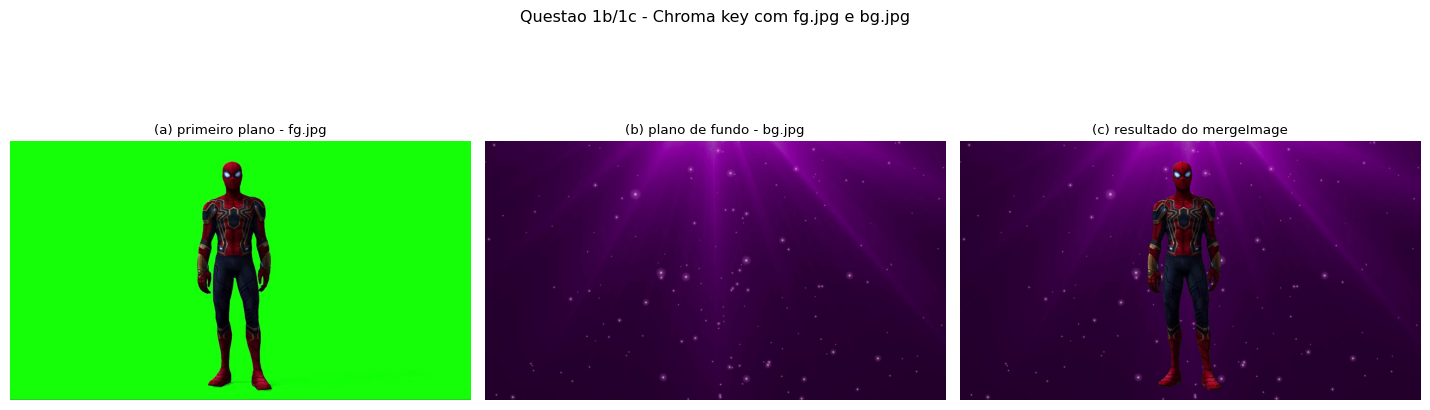

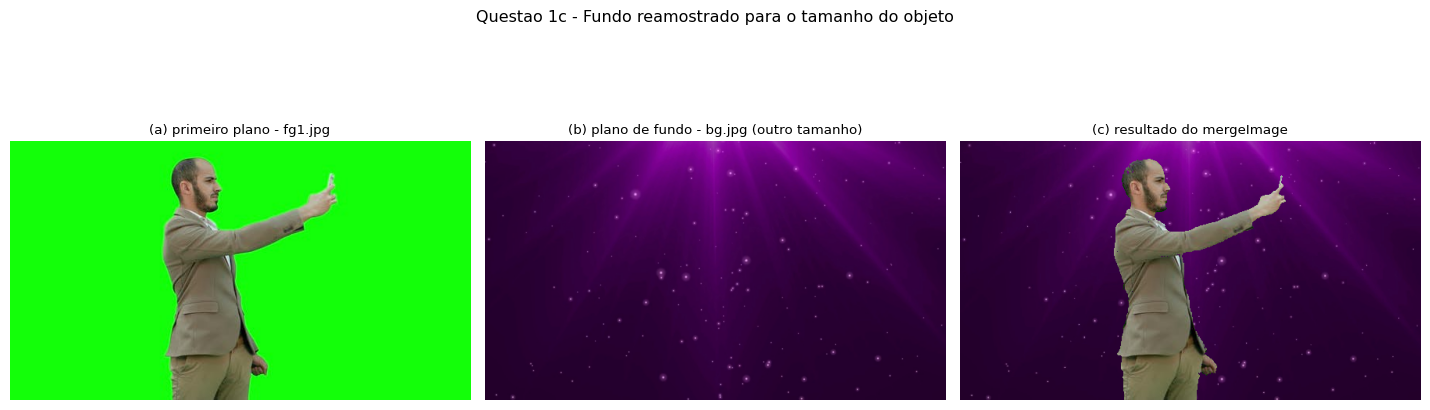

In [17]:
def main():
    #1a) mostra a cor dominante de fg1 como um retangulo solido
    fg1 = load_img("fg1.jpg")
    cor_fg1, qtd_fg1 = cor_mais_frequente(fg1)

    amostra = np.zeros((120, 120, 3), dtype=np.uint8)
    amostra[:, :] = cor_fg1

    show_images([fg1, amostra],
                ["fg1.jpg", f"Cor dominante RGB {cor_fg1}"],
                suptitle="Questao 1a - Cor de maior frequencia",
                figsize=(10, 4))

    #1b e 1c) mergeImage com dois pares de imagens
    bg1 = load_img("bg1.jpg")
    img_out1 = mergeImage(fg1, bg1)
    show_images([fg1, bg1, img_out1],
                ["(a) primeiro plano - fg1.jpg",
                 "(b) plano de fundo - bg1.jpg",
                 "(c) resultado do mergeImage"],
                suptitle="Questao 1b/1c - Chroma key com fg1.jpg e bg1.jpg")

    fg2 = load_img("fg.jpg")
    bg2 = load_img("bg.jpg")
    img_out2 = mergeImage(fg2, bg2)
    show_images([fg2, bg2, img_out2],
                ["(a) primeiro plano - fg.jpg",
                 "(b) plano de fundo - bg.jpg",
                 "(c) resultado do mergeImage"],
                suptitle="Questao 1b/1c - Chroma key com fg.jpg e bg.jpg")

    #teste com fundo de tamanho diferente
    img_out3 = mergeImage(fg1, bg2)
    show_images([fg1, bg2, img_out3],
                ["(a) primeiro plano - fg1.jpg",
                 "(b) plano de fundo - bg.jpg (outro tamanho)",
                 "(c) resultado do mergeImage"],
                suptitle="Questao 1c - Fundo reamostrado para o tamanho do objeto")

main()


### Análise da Questão 1

* **Cor mais frequente:** Na imagem `fg1.jpg`, a cor verde do fundo ocupa cerca de 79% da imagem, por isso a cor mais frequente é a própria cor da tela de chroma key. Já em imagens naturais como `lena.jpg`, as cores são muito variadas e nenhuma cor isolada passa de 1%.
* **Chroma Key:** Usar a proporção relativa ($G > R \cdot 1{,}15$ e $G > B \cdot 1{,}15$) funcionou muito melhor do que fixar um valor absoluto para o verde, pois as imagens `fg1.jpg` e `fg.jpg` possuem tonalidades e iluminações de verde bem diferentes na tela de fundo.


## Questão 2 — Expansão de Contraste

**a)** Função `linContrastStretching(im, a, b)` que leva a faixa de intensidade para
$[a, b]$, pela transformação

$$s = (r - r_{min}) \cdot \frac{b - a}{r_{max} - r_{min}} + a$$

**b)** Entrada e saída lado a lado, com as barras contendo as $k$ cores de maior
frequência.

**c)** Uso em múltiplas imagens e justificativa da diferença de efeito.

In [5]:
# 2b)barra com os k tons de cinza mais frequentes da imagem
def barra_de_cores(im, k=10, altura=40, largura=40):
    #histograma manual
    histogram = calcular_histograma(im)

    #os k tons de maior frequencia, do mais frequente para o menos frequente
    top_k = np.argsort(histogram)[-k:][::-1]

    #cada tom vira uma faixa vertical de largura fixa
    barra = np.zeros((altura, k * largura), dtype=np.uint8)
    for i, tom in enumerate(top_k):
        barra[:, i * largura : (i + 1) * largura] = tom

    frequencias = [int(histogram[t]) for t in top_k]

    return barra, top_k, frequencias

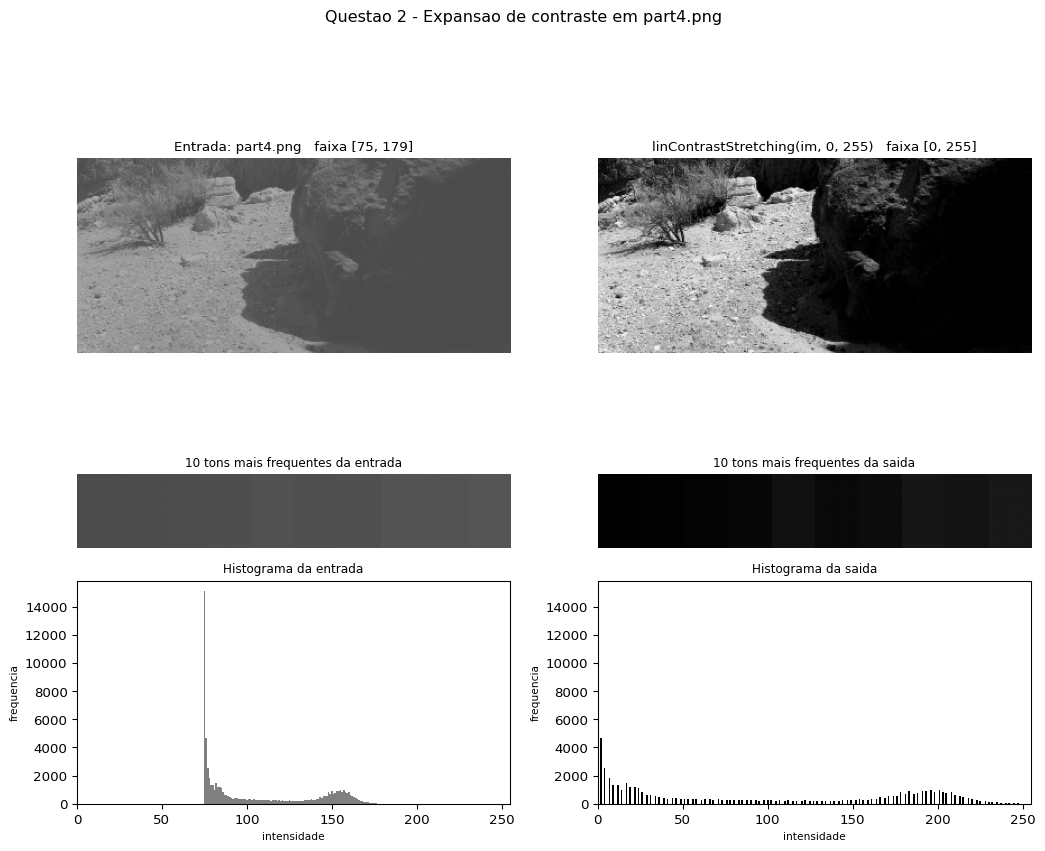

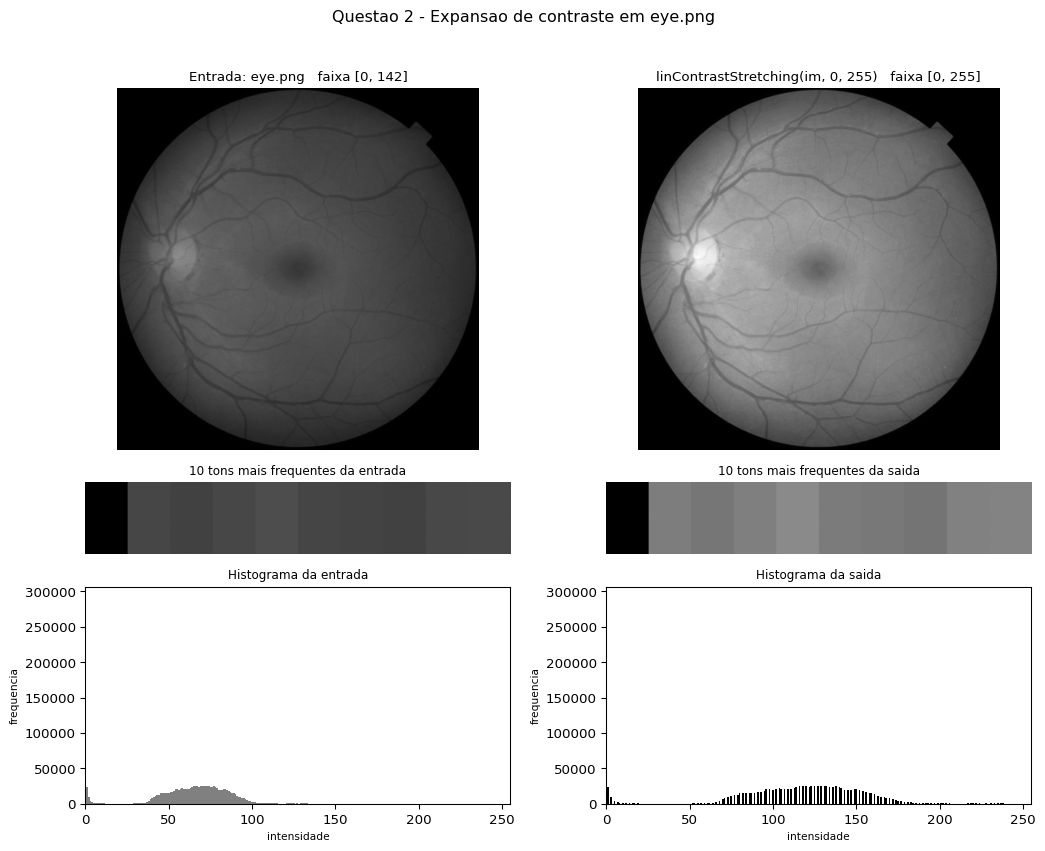

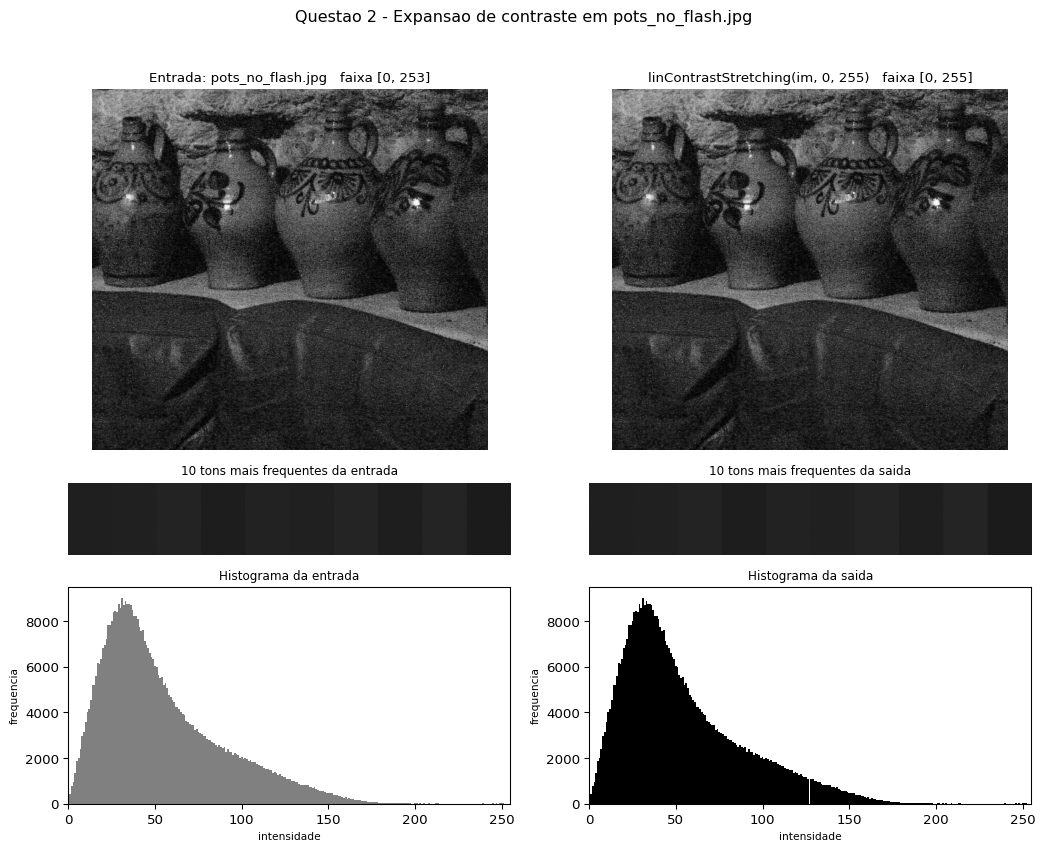

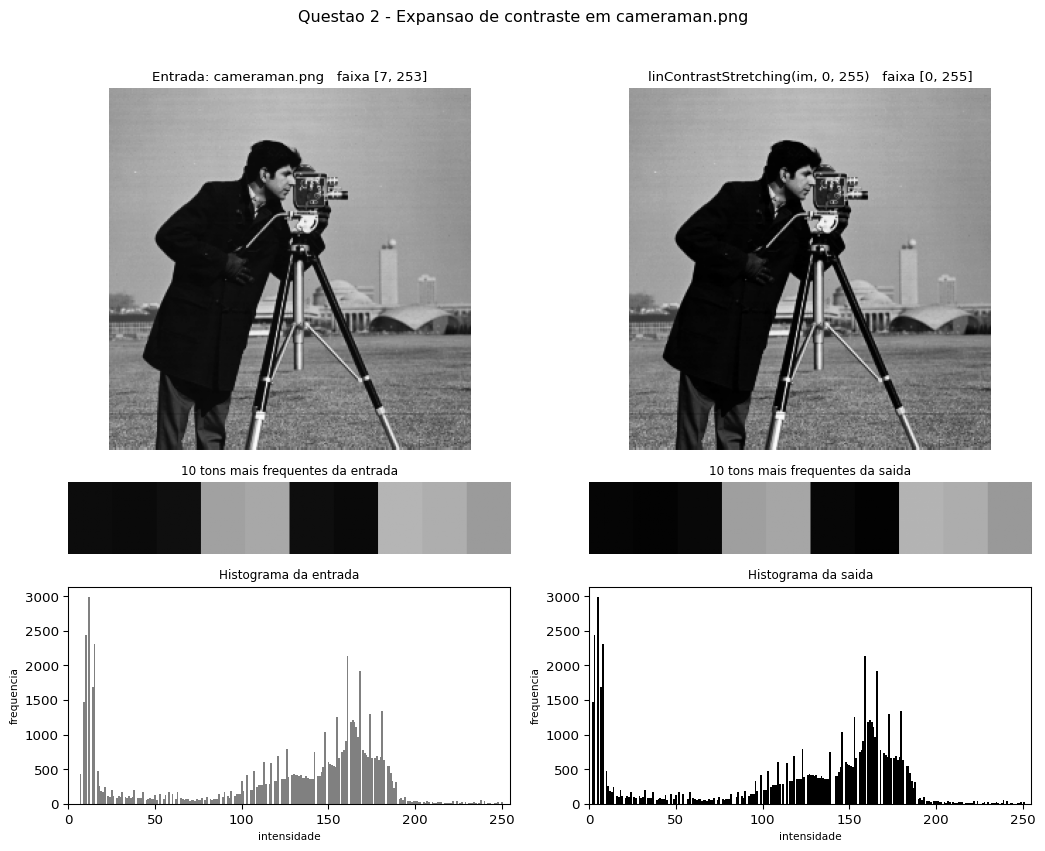

In [18]:
def main():
    #conjunto de imagens para avaliar imagens de faixa estreita e faixa larga
    imagens = ["part4.png", "eye.png", "pots_no_flash.jpg", "cameraman.png"]

    for nome in imagens:
        img_in = load_img(nome, grayscale=True)

        #2a) alargamento para a faixa cheia [0, 255]
        img_out = linContrastStretching(img_in, 0, 255)

        #2b) barras com os 10 tons mais frequentes de cada imagem
        barra_in, top_in, freq_in = barra_de_cores(img_in, k=10)
        barra_out, top_out, freq_out = barra_de_cores(img_out, k=10)

        fig, axes = plt.subplots(3, 2, figsize=(11, 9),
                                 gridspec_kw={"height_ratios": [5, 1, 3]})

        axes[0, 0].imshow(img_in, cmap="gray", vmin=0, vmax=255)
        axes[0, 0].set_title(f"Entrada: {nome}   faixa [{img_in.min()}, {img_in.max()}]", fontsize=10)
        axes[0, 0].axis("off")

        axes[0, 1].imshow(img_out, cmap="gray", vmin=0, vmax=255)
        axes[0, 1].set_title(f"linContrastStretching(im, 0, 255)   faixa [{img_out.min()}, {img_out.max()}]", fontsize=10)
        axes[0, 1].axis("off")

        axes[1, 0].imshow(barra_in, cmap="gray", vmin=0, vmax=255, aspect="auto")
        axes[1, 0].set_title("10 tons mais frequentes da entrada", fontsize=9)
        axes[1, 0].axis("off")

        axes[1, 1].imshow(barra_out, cmap="gray", vmin=0, vmax=255, aspect="auto")
        axes[1, 1].set_title("10 tons mais frequentes da saida", fontsize=9)
        axes[1, 1].axis("off")

        plotar_histograma(axes[2, 0], img_in, "Histograma da entrada")
        plotar_histograma(axes[2, 1], img_out, "Histograma da saida", cor="black")

        fig.suptitle(f"Questao 2 - Expansao de contraste em {nome}", fontsize=12)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

main()


### Análise da Questão 2

* **Barras de cores (2b):** Na imagem original, os 10 tons mais frequentes ficavam todos amontoados e quase não dava para ver diferença entre eles. Depois do alargamento linear, esses tons são espalhados pela escala de 0 a 255, ficando bem fáceis de distinguir. No histograma dá para ver que os tons se afastaram, deixando alguns espaços vazios entre as barras.
* **Diferença de efeito (2c):**
  * Em `part4.png` e `eye.png` o efeito é muito forte porque os pixels originais estavam todos espremidos (baixo contraste).
  * Em `cameraman.png` a imagem já usava quase toda a faixa (7 a 253), então quase não muda nada.
  * Em `pots_no_flash.jpg`, embora a foto seja escura, ela tem alguns pontinhos isolados de ruído em 0 e 253. Como a fórmula olha só o menor e o maior valor, o contraste acaba travando e não muda nada.


## Questão 3 — Transformações de Intensidade

**a)** Função para o negativo, recebendo a imagem e a intensidade máxima, aplicada às 8
primeiras formas quantizadas em $k$ bits de `lena.jpg`.

**b)** Transformação gama $s = r^{\gamma}$ em `gamma-corr.png`, variando $\gamma$.

**c)** Transformação linear por partes $g(z) = K_1^i \cdot z + K_2^i$ para
$a^i \leq z \leq b^i$, com os coeficientes das duas funções do enunciado.

In [7]:
#3a) negativo: s = L_max - r
def gerar_negativo(im, intensidade_maxima=255):
    img_in = im.astype(float)

    img_out = float(intensidade_maxima) - img_in

    return para_uint8(img_out)

#quantizacao em k bits, ou seja, 2^k niveis de cinza
def quantizar_imagem(im, k_bits):
    n_niveis = 2 ** k_bits
    degrau = 256.0 / n_niveis

    img_in = im.astype(float)

    #cada pixel cai no degrau correspondente e recebe o valor central dele
    img_out = np.floor(img_in / degrau) * degrau + (degrau / 2.0)

    return para_uint8(img_out)

#3b) transformacao gama: s = c * r^gamma
def transformacao_gama(im, gamma, c=1.0):
    img_in = im.astype(float)

    #normaliza para [0, 1], aplica a potencia e volta para [0, 255]
    img_out = c * 255.0 * ((img_in / 255.0) ** gamma)

    return para_uint8(img_out)

#3c) transformacao linear por partes: g(z) = K1*z + K2 para a <= z <= b
def transformacao_linear_partes(im, K1_list, K2_list, a_list, b_list):
    img_in = im.astype(float)
    img_out = np.zeros(img_in.shape, dtype=float)

    #cada segmento cuida da sua faixa de intensidade
    for k1, k2, a, b in zip(K1_list, K2_list, a_list, b_list):
        mascara = (img_in >= a) & (img_in <= b)
        img_out[mascara] = k1 * img_in[mascara] + k2

    return para_uint8(img_out)

# desenha a curva g(z) de uma transformacao linear por partes
def plotar_curva(ax, K1_list, K2_list, a_list, b_list, titulo):
    z = np.arange(256, dtype=float)
    g = np.zeros(256, dtype=float)
    for k1, k2, a, b in zip(K1_list, K2_list, a_list, b_list):
        mascara = (z >= a) & (z <= b)
        g[mascara] = k1 * z[mascara] + k2

    ax.plot(z / 255.0, np.clip(g, 0, 255) / 255.0, color="#c0504d", linewidth=1.6)
    ax.set_title(titulo, fontsize=9)
    ax.set_xlabel("z (entrada)", fontsize=8)
    ax.set_ylabel("g(z) (saida)", fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=":", alpha=0.5)

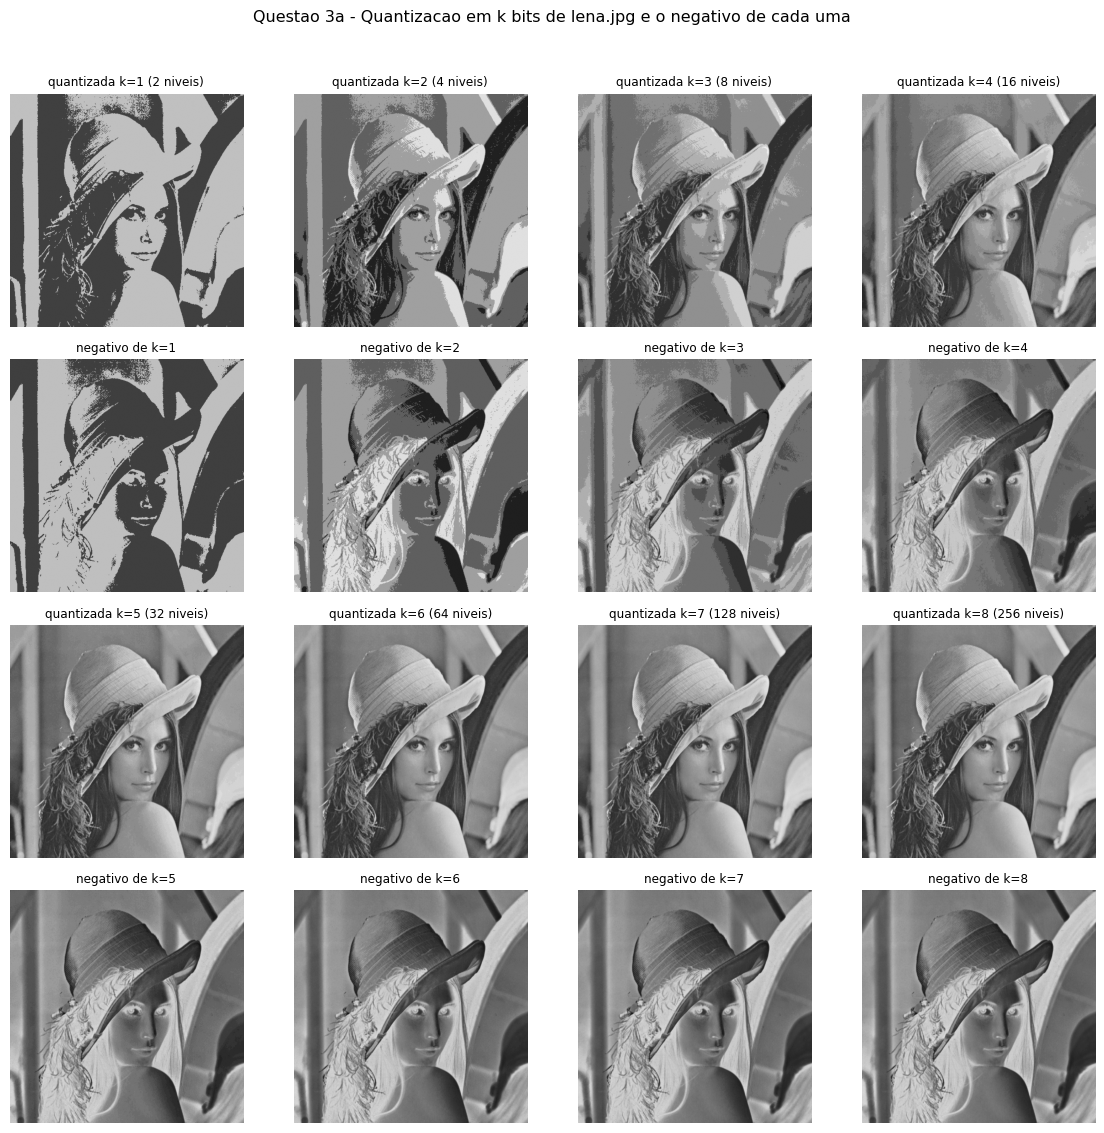

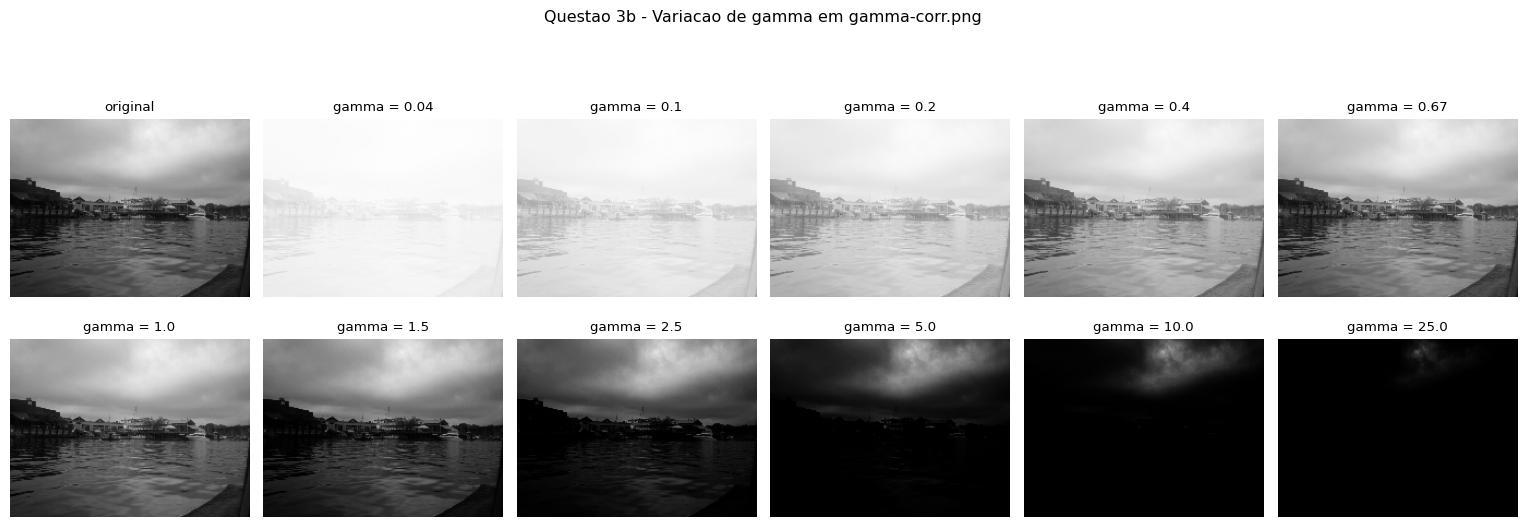

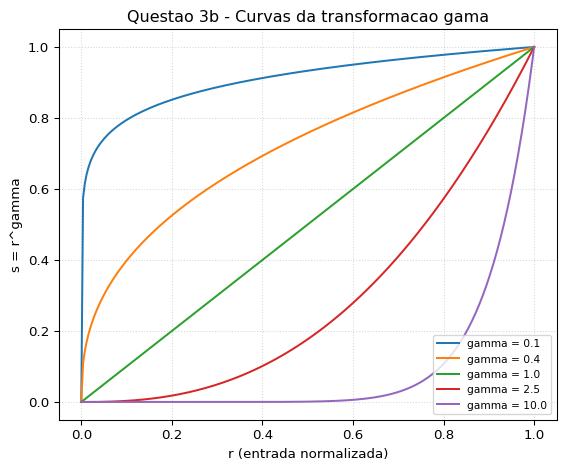

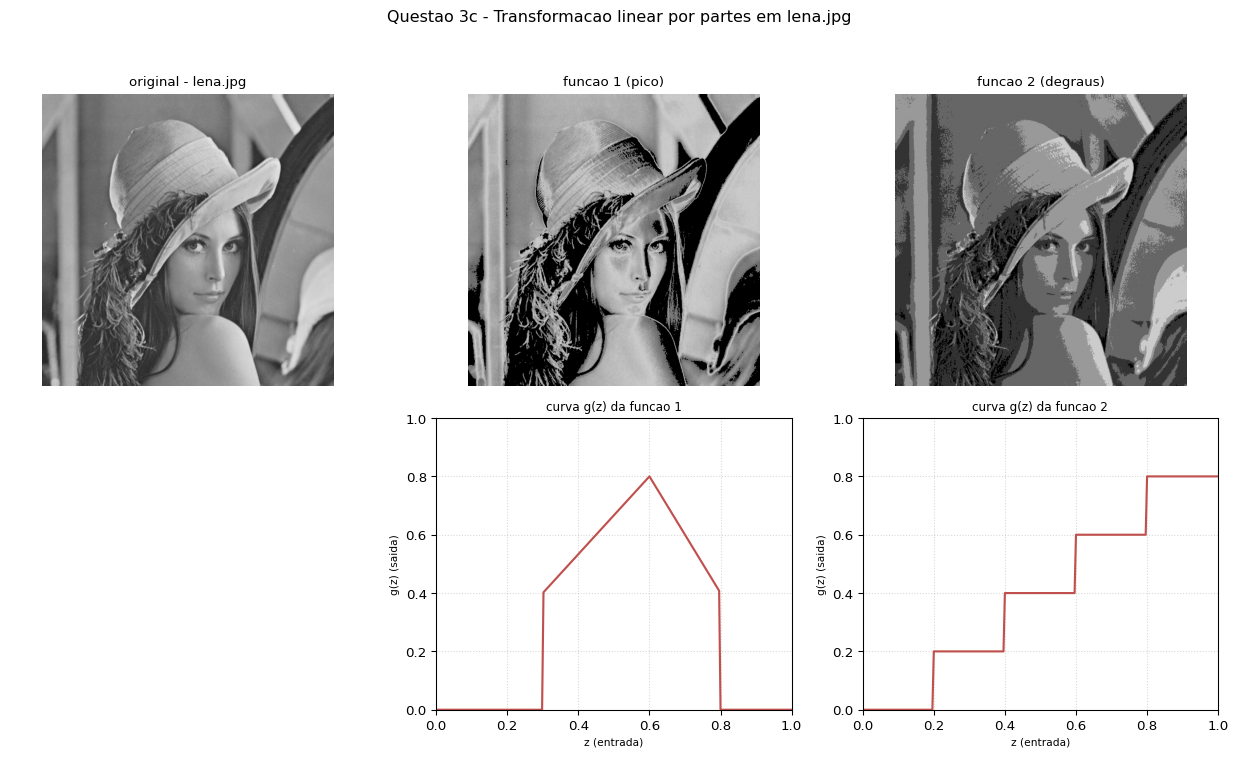

In [19]:
def main():

    lena = load_img("lena.jpg", grayscale=True)

    #3a) as 8 primeiras quantizacoes de lena.jpg e seus negativos
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))

    for bloco, faixa in enumerate([range(1, 5), range(5, 9)]):
        for idx, k in enumerate(faixa):
            quantizada = quantizar_imagem(lena, k)
            negativo = gerar_negativo(quantizada, 255)

            axes[bloco * 2, idx].imshow(quantizada, cmap="gray", vmin=0, vmax=255)
            axes[bloco * 2, idx].set_title(f"quantizada k={k} ({2**k} niveis)", fontsize=9)
            axes[bloco * 2, idx].axis("off")

            axes[bloco * 2 + 1, idx].imshow(negativo, cmap="gray", vmin=0, vmax=255)
            axes[bloco * 2 + 1, idx].set_title(f"negativo de k={k}", fontsize=9)
            axes[bloco * 2 + 1, idx].axis("off")

    fig.suptitle("Questao 3a - Quantizacao em k bits de lena.jpg e o negativo de cada uma", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    #3b) transformacao gama
    gamma_img = load_img("gamma-corr.png", grayscale=True)
    valores_gamma = [0.04, 0.1, 0.2, 0.4, 0.67, 1.0, 1.5, 2.5, 5.0, 10.0, 25.0]

    fig, axes = plt.subplots(2, 6, figsize=(16, 6))
    axes_flat = axes.ravel()

    axes_flat[0].imshow(gamma_img, cmap="gray", vmin=0, vmax=255)
    axes_flat[0].set_title("original", fontsize=10)
    axes_flat[0].axis("off")

    for i, g in enumerate(valores_gamma):
        img_out = transformacao_gama(gamma_img, g)
        axes_flat[i + 1].imshow(img_out, cmap="gray", vmin=0, vmax=255)
        axes_flat[i + 1].set_title(f"gamma = {g}", fontsize=10)
        axes_flat[i + 1].axis("off")

    fig.suptitle("Questao 3b - Variacao de gamma em gamma-corr.png", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    #curvas de resposta da transformacao gama
    fig, ax = plt.subplots(figsize=(6, 5))
    r = np.arange(256) / 255.0
    for g in [0.1, 0.4, 1.0, 2.5, 10.0]:
        ax.plot(r, r ** g, label=f"gamma = {g}")
    ax.set_xlabel("r (entrada normalizada)")
    ax.set_ylabel("s = r^gamma")
    ax.set_title("Questao 3b - Curvas da transformacao gama")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

    #3c) transformacao linear por partes, com os coeficientes dos graficos do enunciado

    #funcao 1 do enunciado: zero ate 0.3, sobe de (0.3, 0.4) ate (0.6, 0.8),
    #desce de (0.6, 0.8) ate (0.8, 0.4) e volta a zero.
    f1 = dict(
        K1_list=[0.0, 4.0 / 3.0, -2.0, 0.0],
        K2_list=[0.0, 0.0, 2.0 * 255.0, 0.0],
        a_list=[0.0, 0.3 * 255.0, 0.6 * 255.0, 0.8 * 255.0],
        b_list=[0.3 * 255.0, 0.6 * 255.0, 0.8 * 255.0, 1.0 * 255.0],
    )

    #funcao 2 do enunciado: cinco degraus constantes de 0.2 em 0.2
    f2 = dict(
        K1_list=[0.0, 0.0, 0.0, 0.0, 0.0],
        K2_list=[0.0, 0.2 * 255.0, 0.4 * 255.0, 0.6 * 255.0, 0.8 * 255.0],
        a_list=[0.0, 0.2 * 255.0, 0.4 * 255.0, 0.6 * 255.0, 0.8 * 255.0],
        b_list=[0.2 * 255.0, 0.4 * 255.0, 0.6 * 255.0, 0.8 * 255.0, 1.0 * 255.0],
    )

    img_out_f1 = transformacao_linear_partes(lena, **f1)
    img_out_f2 = transformacao_linear_partes(lena, **f2)

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))

    axes[0, 0].imshow(lena, cmap="gray", vmin=0, vmax=255)
    axes[0, 0].set_title("original - lena.jpg", fontsize=10)
    axes[0, 0].axis("off")
    axes[0, 1].imshow(img_out_f1, cmap="gray", vmin=0, vmax=255)
    axes[0, 1].set_title("funcao 1 (pico)", fontsize=10)
    axes[0, 1].axis("off")
    axes[0, 2].imshow(img_out_f2, cmap="gray", vmin=0, vmax=255)
    axes[0, 2].set_title("funcao 2 (degraus)", fontsize=10)
    axes[0, 2].axis("off")

    axes[1, 0].axis("off")
    plotar_curva(axes[1, 1], titulo="curva g(z) da funcao 1", **f1)
    plotar_curva(axes[1, 2], titulo="curva g(z) da funcao 2", **f2)

    fig.suptitle("Questao 3c - Transformacao linear por partes em lena.jpg", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

main()

### Análise da Questão 3

* **Quantização e Negativo (3a):** Com poucos bits ($k=1$ ou $2$), aparecem degraus visíveis na imagem (falsos contornos). O negativo apenas inverte o preto com o branco ($255 - r$), mantendo exatamente a mesma quantidade de níveis.
* **Transformação Gama (3b):**
  * $\gamma < 1$: clareia a imagem e revela detalhes no escuro.
  * $\gamma = 1$: não muda nada (imagem original).
  * $\gamma > 1$: escurece a imagem e comprime os tons claros.
* **Linear por Partes (3c):**
  * **Função 1 (Pico):** Isola apenas os tons médios da Lena e apaga o restante (fica tudo preto nas partes muito claras ou muito escuras).
  * **Função 2 (Degraus):** Funciona como uma quantização em apenas 5 níveis de cinza constantes.


## Questão 4 — Equalização e Correspondência de Histogramas

**a)** Função `histEqualization(im)` aplicada à imagem inteira.

**b)** Entrada e saída lado a lado, com explicação, em múltiplas imagens.

**c)** Função `histMatching(entrada, referencia)` usando `eye.png` e `eyeref.png`.

**d)** Recuperação de `canyon.png` a partir de `part1.png` a `part4.png`.

A equalização segue a sequência vista em aula: contagem, função densidade de
probabilidade, função distribuição acumulada, tabela de mapeamento arredondada para a
escala $[0, 255]$ e aplicação por indexação direta.

In [20]:
#4a) equalizacao de histograma
#contagem -> pdf -> cdf -> tabela de mapeamento -> indexacao direta
def histEqualization(im):
    #1. histograma com 256 posicoes
    point_count = calcular_histograma(im)

    #2. funcao densidade de probabilidade
    pdf = point_count / np.sum(point_count)

    #3. funcao distribuicao acumulada
    cdf = np.cumsum(pdf)

    #4. tabela de mapeamento levando a cdf para a escala [0, 255]
    f_eq = np.round(cdf * 255).astype(int)

    #5.a tabela e aplicada usando a propria imagem como indice
    img_eq = f_eq[im]

    return np.array(img_eq, dtype=np.uint8)

#4c) casamento (especificacao) de histogramas
def histMatching(im_source, im_reference):
    #cdf da imagem de entrada
    hist_s = calcular_histograma(im_source)
    cdf_s = np.cumsum(hist_s / np.sum(hist_s))

    #cdf da imagem de referencia
    hist_r = calcular_histograma(im_reference)
    cdf_r = np.cumsum(hist_r / np.sum(hist_r))

    #para cada tom da entrada, procura o tom da referencia de cdf mais proxima
    mapeamento = np.zeros(256, dtype=np.uint8)
    for s in range(256):
        mapeamento[s] = np.argmin(np.abs(cdf_r - cdf_s[s]))

    return mapeamento[im_source]

In [22]:
def main():

    #4a e 4b) equalizacao em multiplas imagens
    for nome in ["contrast.jpg", "pots_no_flash.jpg", "cameraman.png", "mri.png"]:
        img_in = load_img(nome, grayscale=True)
        img_out = histEqualization(img_in)

        fig, axes = plt.subplots(2, 2, figsize=(11, 8))

        axes[0, 0].imshow(img_in, cmap="gray", vmin=0, vmax=255)
        axes[0, 0].set_title(f"entrada: {nome}", fontsize=10)
        axes[0, 0].axis("off")

        axes[0, 1].imshow(img_out, cmap="gray", vmin=0, vmax=255)
        axes[0, 1].set_title("apos histEqualization", fontsize=10)
        axes[0, 1].axis("off")

        plotar_histograma(axes[1, 0], img_in, "histograma da entrada")
        plotar_histograma(axes[1, 1], img_out, "histograma equalizado", cor="black")

        fig.suptitle(f"Questao 4a/4b - Equalizacao de histograma em {nome}", fontsize=12)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    #4c) casamento de histogramas com eye.png e eyeref.png
    eye = load_img("eye.png", grayscale=True)
    eyeref = load_img("eyeref.png", grayscale=True)
    eye_matched = histMatching(eye, eyeref)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    for col, (img, tit) in enumerate([(eye, "entrada: eye.png"),
                                      (eyeref, "referencia: eyeref.png"),
                                      (eye_matched, "saida do histMatching")]):
        axes[0, col].imshow(img, cmap="gray", vmin=0, vmax=255)
        axes[0, col].set_title(tit, fontsize=10)
        axes[0, col].axis("off")

    plotar_histograma(axes[1, 0], eye, "histograma da entrada")
    plotar_histograma(axes[1, 1], eyeref, "histograma da referencia")
    plotar_histograma(axes[1, 2], eye_matched, "histograma da saida", cor="black")

    fig.suptitle("Questao 4c - Correspondencia de histogramas", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    #comparacao das cdfs, que e o que o casamento realmente aproxima
    fig, ax = plt.subplots(figsize=(7, 5))
    for img, rot in [(eye, "entrada"), (eyeref, "referencia"), (eye_matched, "saida")]:
        h = calcular_histograma(img)
        ax.plot(np.cumsum(h / np.sum(h)), label=rot)
    ax.set_xlabel("intensidade")
    ax.set_ylabel("frequencia acumulada")
    ax.set_title("Questao 4c - A cdf da saida acompanha a da referencia")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

    #4d) recuperacao de canyon.png a partir dos quatro quadrantes
    #figura 5 do enunciado, com os quatro pedacos
    show_images([load_img("q4.png")], ["Figura 5 do enunciado (q4.png)"],
                suptitle="Questao 4d - Os quatro quadrantes fornecidos", figsize=(12, 5))

    canyon = load_img("canyon.png", grayscale=True)
    partes = [load_img(f"part{i}.png", grayscale=True) for i in (1, 2, 3, 4)]

    altura, largura = canyon.shape
    #o corte nao e largura 2: as partes da esquerda tem uma coluna a mais,
    #porque canyon.png tem largura impar. Usamos o tamanho real das partes.
    meia_altura = partes[0].shape[0]
    meia_largura = partes[0].shape[1]

    def montar(quadrantes):
        mosaico = np.zeros((altura, largura), dtype=np.uint8)
        mosaico[:meia_altura, :meia_largura] = quadrantes[0]
        mosaico[:meia_altura, meia_largura:] = quadrantes[1]
        mosaico[meia_altura:, :meia_largura] = quadrantes[2]
        mosaico[meia_altura:, meia_largura:] = quadrantes[3]
        return mosaico

    def erro_medio(mosaico):
        return np.abs(mosaico.astype(float) - canyon.astype(float)).mean()

    #as faixas de intensidade mostram que cada quadrante sofreu uma compressao
    #linear de contraste diferente. Desfazemos isso alargando cada quadrante de
    #volta para a escala cheia.
    mosaico_bruto = montar(partes)
    recuperada = montar([linContrastStretching(p, 0, 255) for p in partes])

    #alternativa testada: equalizar cada quadrante isoladamente
    equalizada = montar([histEqualization(p) for p in partes])

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for ax, img, tit in zip(axes.ravel(),
                            [mosaico_bruto, equalizada, recuperada, canyon],
                            ["(1) mosaico bruto das quatro partes",
                             "(2) equalizacao em cada quadrante",
                             "(3) alargamento linear em cada quadrante",
                             "(4) canyon.png original, para comparacao"]):
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax.set_title(tit, fontsize=10)
        ax.axis("off")
    fig.suptitle("Questao 4d - Recuperacao da imagem original", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

main()


Output hidden; open in https://colab.research.google.com to view.

### Análise da Questão 4

* **Equalização (4b):**
  * A equalização espalha os pixels usando a CDF. Onde há muitos pixels juntos, os tons são afastados aumentando o contraste.
  * Em `pots_no_flash.jpg`, a equalização funciona muito melhor que o alargamento da Q2 porque ela olha a distribuição de todos os pixels, e não apenas o menor e o maior.
  * Em `mri.png` acontece o contrário: como o fundo preto ocupa quase toda a imagem, a equalização foca no fundo e acaba piorando o contraste do cérebro (conteúdo útil).

* **Casamento de Histogramas (4c):**
  * A imagem `eye.png` é escura (máximo 142). Ao casar com `eyeref.png`, ela herda a iluminação e o brilho da referência sem perder os detalhes do olho. No gráfico das CDFs, a curva da saída fica colada na curva de referência.

* **Recuperação de `canyon.png` (4d):**
  * Cada quadrante sofreu apenas uma compressão de contraste diferente. Por isso, aplicar `linContrastStretching(parte, 0, 255)` em cada pedaço recupera a imagem perfeitamente e sem emendas.
  * Equalizar cada quadrante não funciona bem porque o céu, a rocha e a sombra têm distribuições naturalmente diferentes.
  * A imagem original `canyon.png` foi usada apenas no final para comparar o resultado e medir o erro, garantindo que não usamos o gabarito como entrada.


## Questão 5 — Subtração do Laplaciano e Mascaramento de Nitidez

Demonstrar que a subtração do Laplaciano de uma imagem é proporcional à técnica de
*unsharp masking*, e comprovar empiricamente.

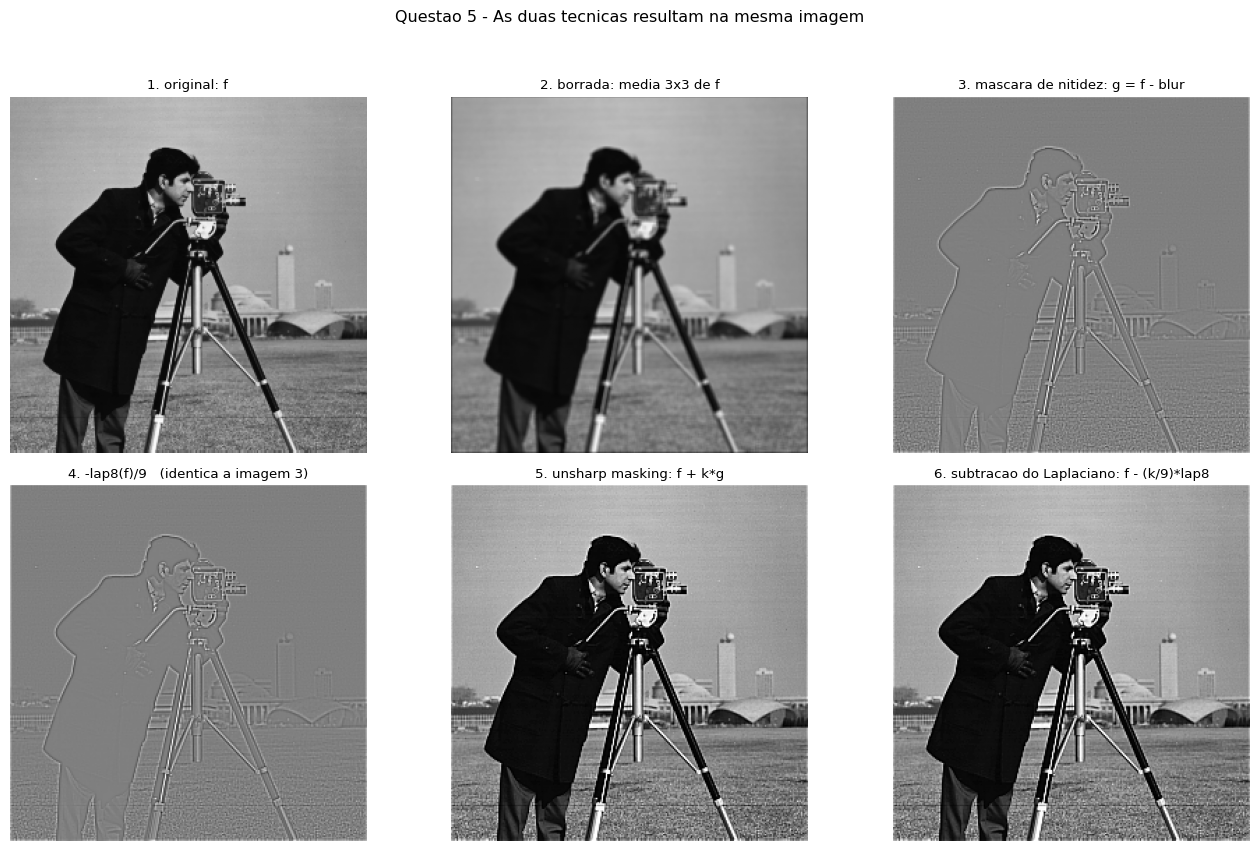

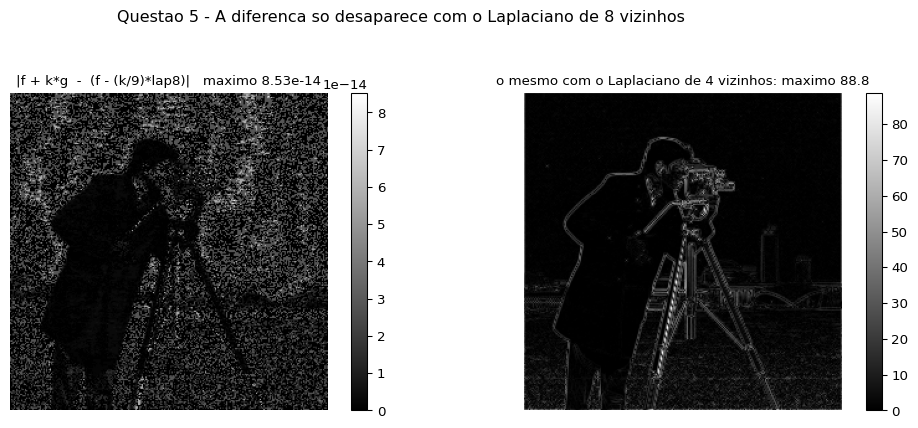

In [23]:
def main():
    im = load_img("cameraman.png", grayscale=True)
    f = im.astype(float)

    #laplaciano de 8 vizinhos, centro negativo
    kernel_lap8 = np.array([[1,  1, 1],
                            [1, -8, 1],
                            [1,  1, 1]], dtype=float)

    #laplaciano de 4 vizinhos
    kernel_lap4 = np.array([[0,  1, 0],
                            [1, -4, 1],
                            [0,  1, 0]], dtype=float)

    #filtro de media 3x3
    kernel_media = np.ones((3, 3), dtype=float) / 9.0

    lap8 = conv2d(f, kernel_lap8)
    lap4 = conv2d(f, kernel_lap4)
    blur = conv2d(f, kernel_media)

    #mascara de nitidez
    g = f - blur

    k = 1.0
    umhf = para_uint8(f + k * g)
    sharpened_lap8 = para_uint8(f - (k / 9.0) * lap8)

    #comparacao visual
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))

    axes[0, 0].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[0, 0].set_title("1. original: f", fontsize=10)
    axes[0, 0].axis("off")

    axes[0, 1].imshow(para_uint8(blur), cmap="gray", vmin=0, vmax=255)
    axes[0, 1].set_title("2. borrada: media 3x3 de f", fontsize=10)
    axes[0, 1].axis("off")

    #o deslocamento de 128 serve so para enxergar valores negativos
    axes[0, 2].imshow(para_uint8(g + 128), cmap="gray", vmin=0, vmax=255)
    axes[0, 2].set_title("3. mascara de nitidez: g = f - blur", fontsize=10)
    axes[0, 2].axis("off")

    axes[1, 0].imshow(para_uint8(-lap8 / 9.0 + 128), cmap="gray", vmin=0, vmax=255)
    axes[1, 0].set_title("4. -lap8(f)/9   (identica a imagem 3)", fontsize=10)
    axes[1, 0].axis("off")

    axes[1, 1].imshow(umhf, cmap="gray", vmin=0, vmax=255)
    axes[1, 1].set_title("5. unsharp masking: f + k*g", fontsize=10)
    axes[1, 1].axis("off")

    axes[1, 2].imshow(sharpened_lap8, cmap="gray", vmin=0, vmax=255)
    axes[1, 2].set_title("6. subtracao do Laplaciano: f - (k/9)*lap8", fontsize=10)
    axes[1, 2].axis("off")

    fig.suptitle("Questao 5 - As duas tecnicas resultam na mesma imagem", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    #mapa de diferenca, para mostrar que nao sobra estrutura nenhuma
    diferenca = np.abs((f + k * g) - (f - (k / 9.0) * lap8))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    im0 = axes[0].imshow(diferenca, cmap="gray")
    axes[0].set_title(f"|f + k*g  -  (f - (k/9)*lap8)|   maximo {diferenca.max():.2e}", fontsize=10)
    axes[0].axis("off")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    #a mesma comparacao usando o Laplaciano de 4 vizinhos, que nao fecha
    diferenca4 = np.abs((f + k * g) - (f - (k / 9.0) * lap4))
    im1 = axes[1].imshow(diferenca4, cmap="gray")
    axes[1].set_title(f"o mesmo com o Laplaciano de 4 vizinhos: maximo {diferenca4.max():.1f}", fontsize=10)
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    fig.suptitle("Questao 5 - A diferenca so desaparece com o Laplaciano de 8 vizinhos", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

main()


### Análise da Questão 5

#### Demonstração Algébrica
A média $3 \times 3$ calcula $\text{blur} = \frac{1}{9}(f + \sum_{\text{8 vizinhos}} f)$.

Substituindo na máscara de nitidez $g = f - \text{blur}$:
$$g = f - \frac{1}{9}(f + \sum_{\text{8 vizinhos}} f) = \frac{1}{9}(8f - \sum_{\text{8 vizinhos}} f) = -\frac{1}{9} (\sum_{\text{8 vizinhos}} f - 8f)$$

Como o termo entre parênteses é exatamente o **Laplaciano de 8 vizinhos** com centro negativo:
$$g = -\frac{1}{9} \nabla_8^2 f$$

Portanto, somar a máscara de nitidez é o mesmo que subtrair o Laplaciano ponderado por $1/9$:
$$f + k \cdot g = f - \frac{k}{9} \nabla_8^2 f$$

* **Comprovação Numérica:** No mapa de resíduo, a diferença entre as duas imagens resultantes é na ordem de $10^{-13}$ (ou seja, zero na precisão da máquina).
* **Por que usamos 8 vizinhos e não 4?** Porque o filtro de média $3 \times 3$ inclui as diagonais. Se usássemos o Laplaciano de 4 vizinhos (que ignora as diagonais), a conta não fecharia e sobraria resíduo na imagem, como mostrado no gráfico da direita.


## Questão 6 — Máscara 3×3 e sua Transposta

Criar uma matriz $3 \times 3$ que, convoluída com `box.png`, produza uma linha branca na
região de transição entre o branco e o preto.

**a)** Convoluir `blur.jpg` com essa matriz e com a transposta dela.

**b)** Repetir com imagens adequadas de escolha própria.

In [24]:
#matriz de prewitt horizontal: diferenca entre a linha de baixo e a de cima
M = np.array([[ 1,  1,  1],
              [ 0,  0,  0],
              [-1, -1, -1]], dtype=float)

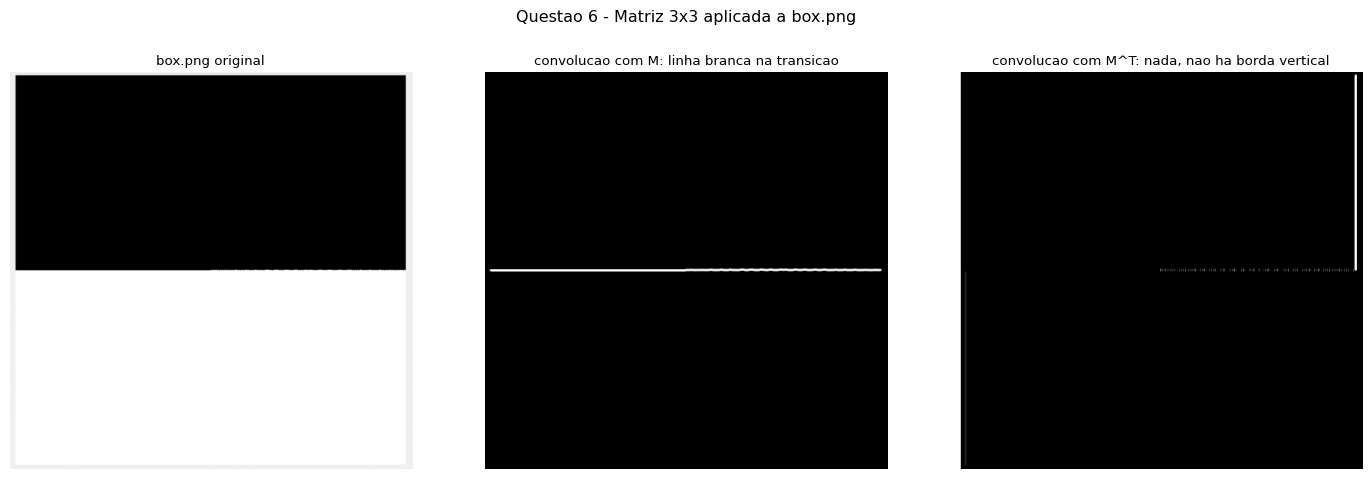

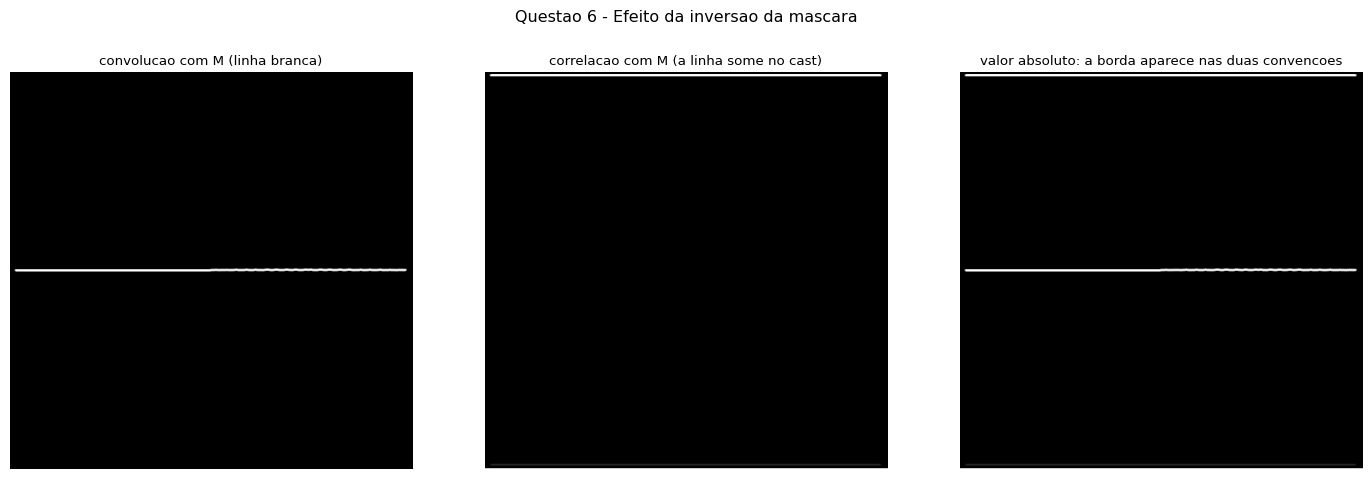

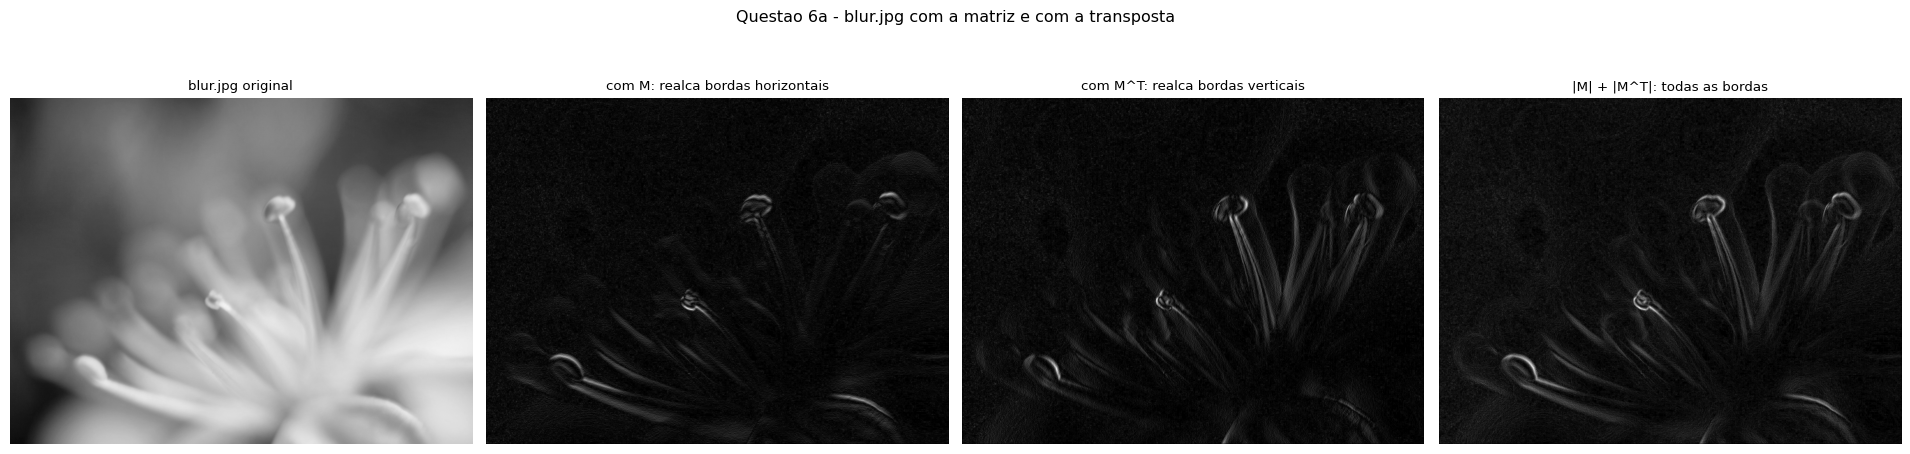

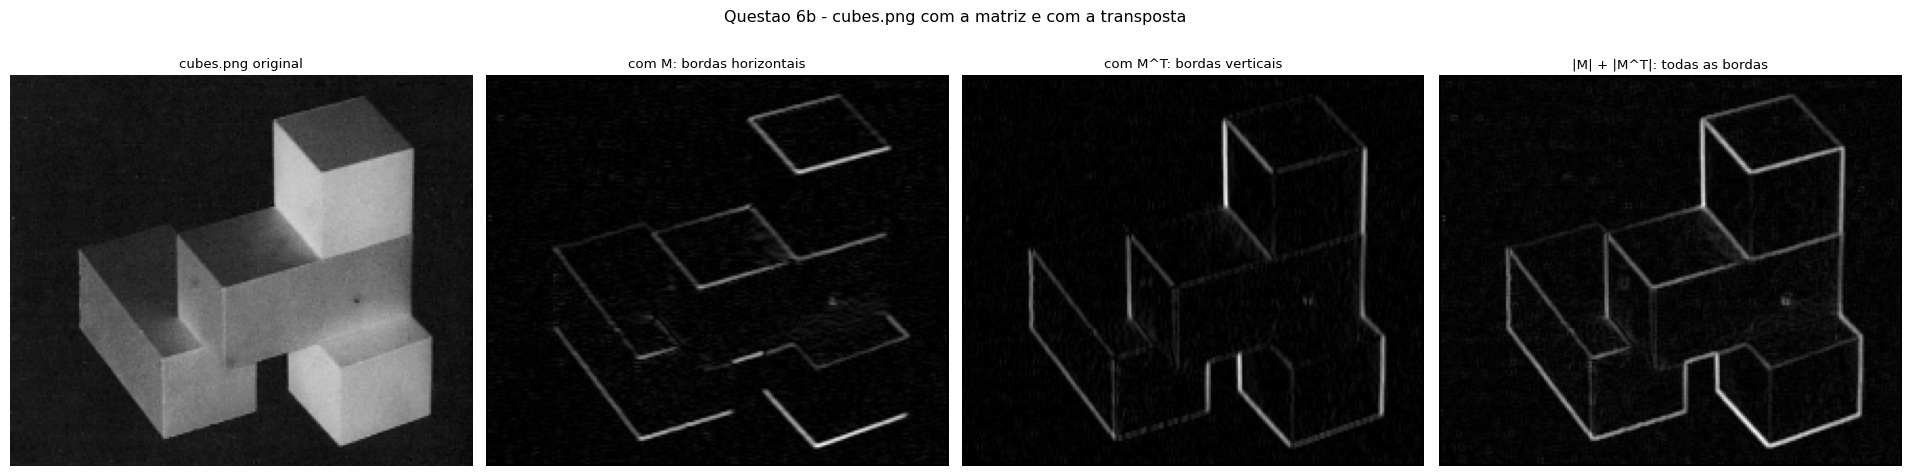

In [25]:
def main():

    box = load_img("box.png", grayscale=True)
    blur_img = load_img("blur.jpg", grayscale=True)
    cubes = load_img("cubes.png", grayscale=True)

    #escolha da matriz
    conv_box = conv2d(box.astype(float), M)
    conv_box_t = conv2d(box.astype(float), M.T)

    show_images([box, para_uint8(conv_box), para_uint8(conv_box_t)],
                ["box.png original",
                 "convolucao com M: linha branca na transicao",
                 "convolucao com M^T: nada, nao ha borda vertical"],
                suptitle="Questao 6 - Matriz 3x3 aplicada a box.png")

    #convolucao e correlacao
    #o conv2d com a mascara ja invertida reproduz a correlacao
    corr_box = conv2d(box.astype(float), M[::-1, ::-1])
    show_images([para_uint8(conv_box), para_uint8(corr_box), para_uint8(np.abs(conv_box))],
                ["convolucao com M (linha branca)",
                 "correlacao com M (a linha some no cast)",
                 "valor absoluto: a borda aparece nas duas convencoes"],
                suptitle="Questao 6 - Efeito da inversao da mascara")

    #6a)blur.jpg com M e com M^T
    for nome, img_in in [("blur.jpg", blur_img)]:
        saida_m = conv2d(img_in.astype(float), M)
        saida_mt = conv2d(img_in.astype(float), M.T)

        #a borda de 1 pixel vem do preenchimento com zeros e distorce a normalizacao
        for saida in (saida_m, saida_mt):
            saida[0, :] = 0
            saida[-1, :] = 0
            saida[:, 0] = 0
            saida[:, -1] = 0

        vis_m = np.array(normalize_minmax(np.abs(saida_m)), dtype=np.uint8)
        vis_mt = np.array(normalize_minmax(np.abs(saida_mt)), dtype=np.uint8)
        vis_mag = np.array(normalize_minmax(np.abs(saida_m) + np.abs(saida_mt)), dtype=np.uint8)

        show_images([img_in, vis_m, vis_mt, vis_mag],
                    [f"{nome} original",
                     "com M: realca bordas horizontais",
                     "com M^T: realca bordas verticais",
                     "|M| + |M^T|: todas as bordas"],
                    suptitle=f"Questao 6a - {nome} com a matriz e com a transposta",
                    figsize=(20, 5))

    #6b) imagem de escolha propria
    saida_m = conv2d(cubes.astype(float), M)
    saida_mt = conv2d(cubes.astype(float), M.T)
    for saida in (saida_m, saida_mt):
        saida[0, :] = 0
        saida[-1, :] = 0
        saida[:, 0] = 0
        saida[:, -1] = 0

    show_images([cubes,
                 np.array(normalize_minmax(np.abs(saida_m)), dtype=np.uint8),
                 np.array(normalize_minmax(np.abs(saida_mt)), dtype=np.uint8),
                 np.array(normalize_minmax(np.abs(saida_m) + np.abs(saida_mt)), dtype=np.uint8)],
                ["cubes.png original",
                 "com M: bordas horizontais",
                 "com M^T: bordas verticais",
                 "|M| + |M^T|: todas as bordas"],
                suptitle="Questao 6b - cubes.png com a matriz e com a transposta",
                figsize=(20, 5))

main()


### Análise da Questão 6

* **Escolha da Matriz $M$:** Como a imagem `box.png` tem preto em cima e branco embaixo, a transição é puramente horizontal. A matriz $M$ calcula a diferença entre a linha de baixo e a de cima:
  $$M = \begin{pmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1 \end{pmatrix}$$
  Nas áreas uniformes o resultado dá zero (tudo preto). Exatamente na transição, a diferença dá $3 \times 255 = 765$, que satura em 255 e gera a linha branca exigida.

* **Convolução vs Correlação:** A convolução matemática inverte o kernel antes de deslizar (`kernel[::-1, ::-1]`), enquanto a correlação não inverte. Como $M$ é antissimétrica, a inversão troca o sinal da saída. Tomando o valor absoluto ($|M|$), as bordas aparecem com clareza em qualquer uma das convenções.

* **Efeito em `blur.jpg` (6a):** A matriz $M$ detecta bordas horizontais e a transposta $M^T$ detecta bordas verticais. Como a foto da flor está desfocada, a transição é gradual (uma rampa suave) e não um degrau abrupto. Por isso, as bordas ficam mais largas e espalhadas.

* **Efeito em `cubes.png` (6b):** Como os cubos possuem arestas retas bem marcadas, a separação fica perfeita: as arestas horizontais aparecem somente em $M$, as arestas verticais aparecem apenas em $M^T$, e as arestas diagonais aparecem em ambas.


## Questão 7 — Filtros Espaciais e Implementação Eficiente

**a)** Filtro passa-baixas de média $k \times k$ na forma `ones(k)/(k**2)`.

**b)** Versão eficiente explorando os pixels compartilhados entre janelas vizinhas, com
gráfico de $k$ contra tempo de execução para imagens de dimensões diferentes.

**c)** Versão eficiente do filtro de mediana, com gráfico semelhante.

As imagens `q7_1.jpeg` e `q7_2.jpg` do dataset são reamostradas para três dimensões, de
modo a gerar uma curva por dimensão sem que a versão padrão demore demais.

In [26]:
#7a) Filtro de media padrao O
def filtro_media_padrao(im, k):
    pad = k // 2
    img_height, img_width = im.shape
    padded_img = add_padding(im.astype(float), pad, pad)

    output = np.zeros((img_height, img_width), dtype=float)
    coeficiente = 1.0 / (k * k)

    for i_img in range(img_height):
        for j_img in range(img_width):
            soma = 0.0
            #soma dos produtos entre a mascara e a vizinhanca
            for i_kernel in range(k):
                for j_kernel in range(k):
                    soma = soma + padded_img[i_img + i_kernel, j_img + j_kernel]
            output[i_img, j_img] = soma * coeficiente

    return np.array(output, dtype=np.uint8)

#7b) Filtro de media eficiente
def filtro_media_eficiente(im, k):
    pad = k // 2
    img_height, img_width = im.shape
    padded_img = add_padding(im.astype(float), pad, pad)

    output = np.zeros((img_height, img_width), dtype=float)
    coeficiente = 1.0 / (k * k)

    #soma vertical de altura k de cada coluna, para a primeira linha
    somas_colunas = np.zeros(padded_img.shape[1], dtype=float)
    for i_kernel in range(k):
        somas_colunas = somas_colunas + padded_img[i_kernel, :]

    for i_img in range(img_height):
        #ao descer uma linha, cada coluna perde o pixel de cima e ganha o de baixo
        if i_img > 0:
            somas_colunas = somas_colunas - padded_img[i_img - 1, :] + padded_img[i_img + k - 1, :]

        #soma da primeira janela da linha
        soma_janela = 0.0
        for j_kernel in range(k):
            soma_janela = soma_janela + somas_colunas[j_kernel]
        output[i_img, 0] = soma_janela * coeficiente

        #ao andar para a direita, perde a coluna que sai e ganha a que entra
        for j_img in range(1, img_width):
            soma_janela = soma_janela - somas_colunas[j_img - 1] + somas_colunas[j_img + k - 1]
            output[i_img, j_img] = soma_janela * coeficiente

    return np.array(output, dtype=np.uint8)

#7c) Filtro de mediana padrao
def filtro_mediana_padrao(im, k):
    pad = k // 2
    img_height, img_width = im.shape
    padded_img = add_padding(im.astype(float), pad, pad)

    output = np.zeros((img_height, img_width), dtype=float)
    indice_mediana = (k * k) // 2

    for i_img in range(img_height):
        for j_img in range(img_width):
            #monta o vetor com os k^2 vizinhos, um a um
            kernel_vectorized = []
            for i_kernel in range(k):
                for j_kernel in range(k):
                    kernel_vectorized.append(padded_img[i_img + i_kernel, j_img + j_kernel])
            #ordena e toma o elemento central
            kernel_vectorized.sort()
            output[i_img, j_img] = kernel_vectorized[indice_mediana]

    return np.array(output, dtype=np.uint8)

# 7c) Filtro de mediana eficiente
def filtro_mediana_eficiente(im, k):
    im_u = np.array(im, dtype=np.uint8)
    pad = k // 2
    img_height, img_width = im_u.shape

    padded_img = np.zeros((img_height + 2 * pad, img_width + 2 * pad), dtype=np.uint8)
    padded_img[pad : pad + img_height, pad : pad + img_width] = im_u

    output = np.zeros((img_height, img_width), dtype=np.uint8)
    alvo = (k * k) // 2 + 1

    for i_img in range(img_height):
        #histograma da primeira janela da linha
        hist = np.bincount(padded_img[i_img : i_img + k, 0 : k].ravel(), minlength=256)

        #localiza a mediana percorrendo o histograma acumulado
        acumulado = 0
        mediana = 0
        for valor in range(256):
            acumulado = acumulado + hist[valor]
            if acumulado >= alvo:
                mediana = valor
                break

        menores = int(np.sum(hist[:mediana]))
        output[i_img, 0] = mediana

        for j_img in range(1, img_width):
            coluna_sai = padded_img[i_img : i_img + k, j_img - 1]
            coluna_entra = padded_img[i_img : i_img + k, j_img + k - 1]

            for p in coluna_sai:
                hist[p] -= 1
                if p < mediana:
                    menores -= 1

            for p in coluna_entra:
                hist[p] += 1
                if p < mediana:
                    menores += 1

            #ajusta a mediana a partir da posicao anterior
            if menores >= alvo:
                while menores >= alvo:
                    mediana -= 1
                    menores -= hist[mediana]
            else:
                while menores + hist[mediana] < alvo:
                    menores += hist[mediana]
                    mediana += 1

            output[i_img, j_img] = mediana

    return output


#benchmark e grafico
def medir(funcao, im, k):
    inicio = time.perf_counter()
    saida = funcao(im, k)
    return (time.perf_counter() - inicio) * 1000.0, saida


def grafico_benchmark(titulo, dimensoes, valores_k, tempos_padrao, tempos_eficiente):
    cores = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]
    fig, ax = plt.subplots(figsize=(9, 6))

    for idx, (altura, largura) in enumerate(dimensoes):
        rot = f"{largura} x {altura}"
        ax.plot(valores_k, tempos_padrao[idx], marker="o", markersize=7,
                color=cores[idx], linestyle="-", label=f"{rot} (versao padrao)")
        ax.plot(valores_k, tempos_eficiente[idx], marker="s", markersize=7,
                color=cores[idx], linestyle="--", label=f"{rot} (versao eficiente)")

    ax.set_xlabel("Tamanho da vizinhanca k")
    ax.set_ylabel("Tempo de execucao (ms)")
    ax.set_xticks(valores_k)
    ax.set_xticklabels([f"{k}x{k}" for k in valores_k])
    ax.set_title(titulo)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.show()


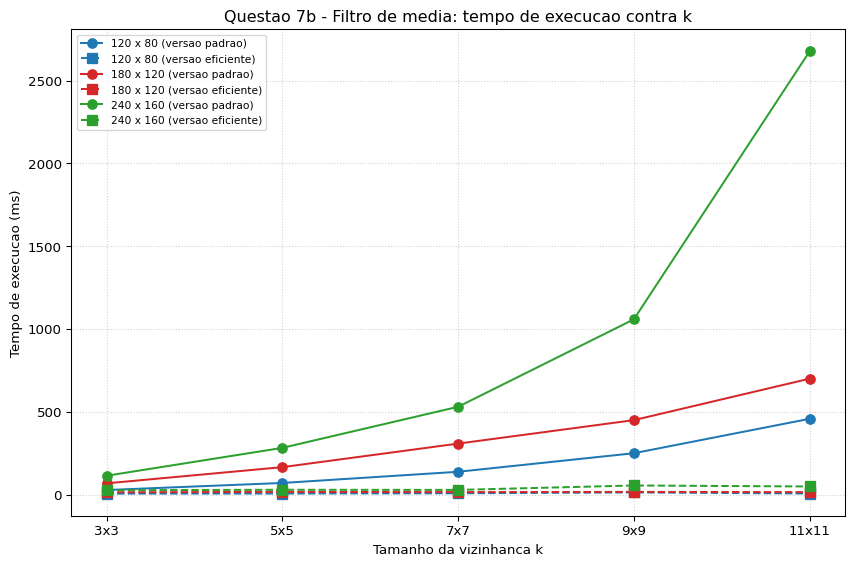

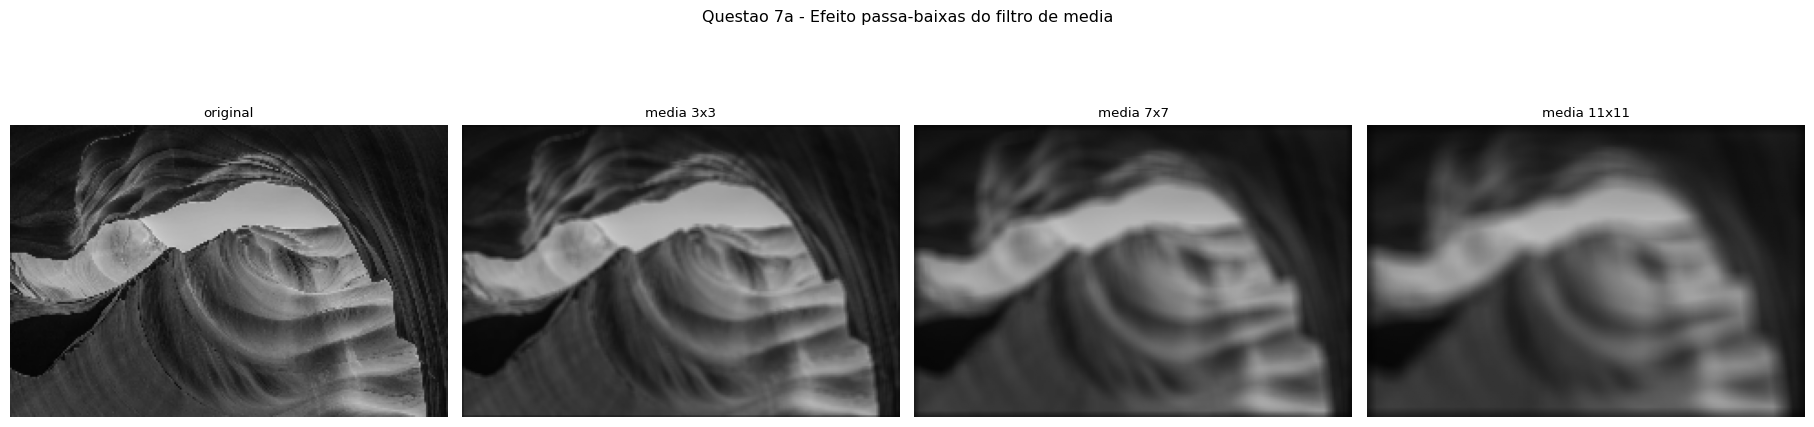

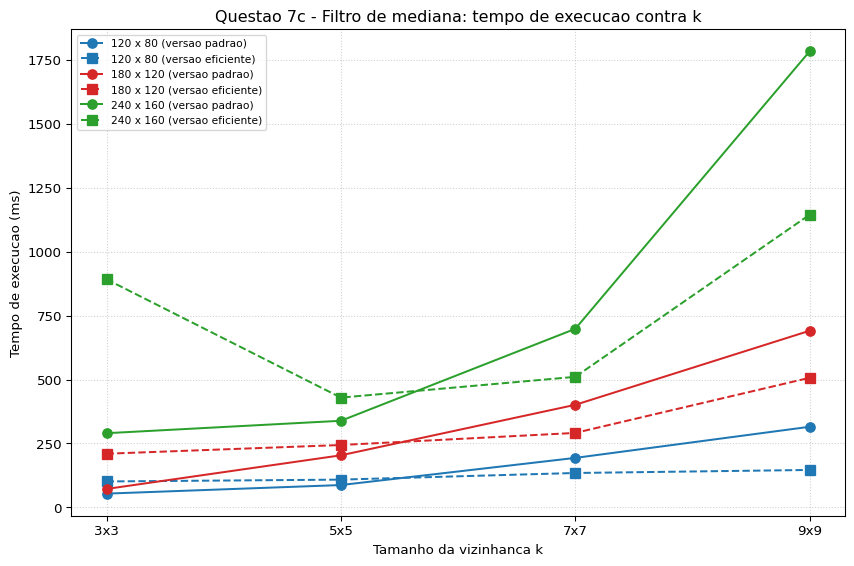

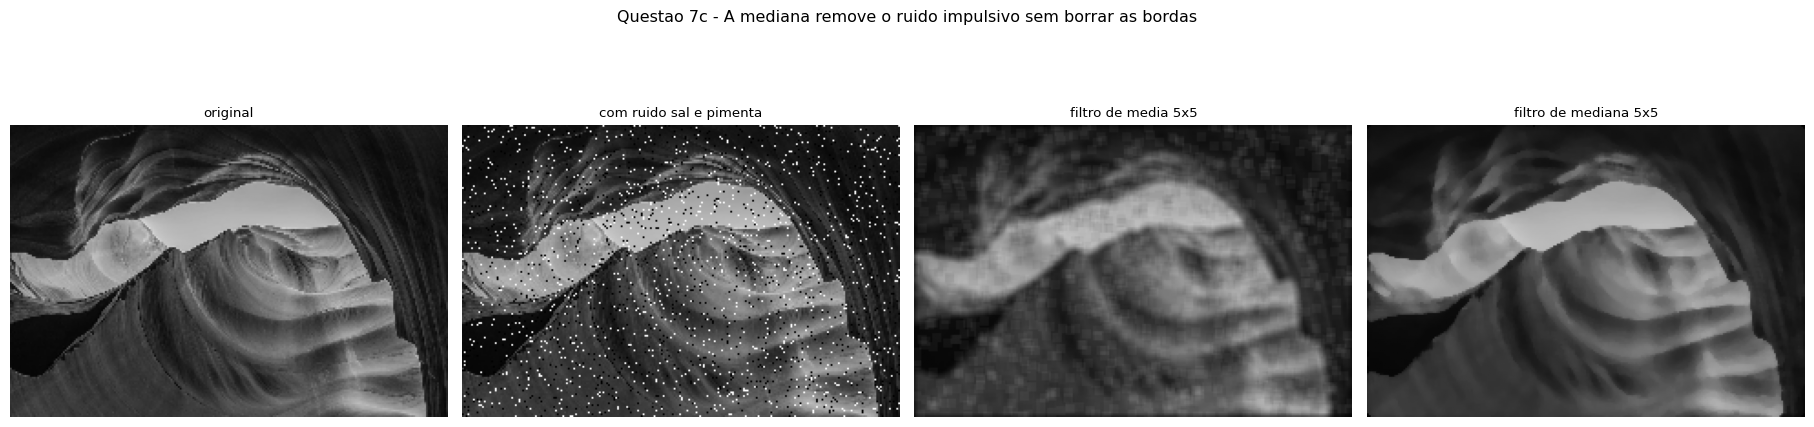

In [27]:
def main():
    #as imagens q7_1 e q7_2 vem do dataset do trabalho e tem dimensoes
    #diferentes. colocamos de novo para tres tamanhos, para gerar uma curva por
    #dimensao sem que a versao padrao demore demais.
    q7_1 = load_img("q7_1.jpeg", grayscale=True)
    q7_2 = load_img("q7_2.jpg", grayscale=True)

    dimensoes = [(80, 120), (120, 180), (160, 240)]
    origens = [q7_2, q7_2, q7_1]
    imagens = [redimensionar(o, a, l) for o, (a, l) in zip(origens, dimensoes)]

    #7a e 7b) filtro de media
    valores_k = [3, 5, 7, 9, 11]

    tempos_padrao = []
    tempos_eficiente = []

    for img_in, (altura, largura) in zip(imagens, dimensoes):
        linha_padrao = []
        linha_eficiente = []
        for k in valores_k:
            t_padrao, saida_padrao = medir(filtro_media_padrao, img_in, k)
            t_eficiente, saida_eficiente = medir(filtro_media_eficiente, img_in, k)

            linha_padrao.append(t_padrao)
            linha_eficiente.append(t_eficiente)

        tempos_padrao.append(linha_padrao)
        tempos_eficiente.append(linha_eficiente)

    grafico_benchmark("Questao 7b - Filtro de media: tempo de execucao contra k",
                      dimensoes, valores_k, tempos_padrao, tempos_eficiente)

    #comparacao visual do filtro de media
    amostra = imagens[2]
    show_images([amostra, filtro_media_padrao(amostra, 3), filtro_media_padrao(amostra, 7),
                 filtro_media_padrao(amostra, 11)],
                ["original", "media 3x3", "media 7x7", "media 11x11"],
                suptitle="Questao 7a - Efeito passa-baixas do filtro de media",
                figsize=(19, 5))

    #7c) filtro de mediana
    valores_k_med = [3, 5, 7, 9]

    tempos_padrao_med = []
    tempos_eficiente_med = []

    for img_in, (altura, largura) in zip(imagens, dimensoes):
        linha_padrao = []
        linha_eficiente = []
        for k in valores_k_med:
            t_padrao, saida_padrao = medir(filtro_mediana_padrao, img_in, k)
            t_eficiente, saida_eficiente = medir(filtro_mediana_eficiente, img_in, k)

            linha_padrao.append(t_padrao)
            linha_eficiente.append(t_eficiente)

        tempos_padrao_med.append(linha_padrao)
        tempos_eficiente_med.append(linha_eficiente)

    grafico_benchmark("Questao 7c - Filtro de mediana: tempo de execucao contra k",
                      dimensoes, valores_k_med, tempos_padrao_med, tempos_eficiente_med)

    #comparacao visual da mediana em ruido sal e pimenta
    rng = np.random.default_rng(0)
    ruidosa = amostra.copy()
    sorteio = rng.random(ruidosa.shape)
    ruidosa[sorteio < 0.03] = 0
    ruidosa[sorteio > 0.97] = 255

    show_images([amostra, ruidosa,
                 filtro_media_eficiente(ruidosa, 5),
                 filtro_mediana_eficiente(ruidosa, 5)],
                ["original", "com ruido sal e pimenta",
                 "filtro de media 5x5", "filtro de mediana 5x5"],
                suptitle="Questao 7c - A mediana remove o ruido impulsivo sem borrar as bordas",
                figsize=(19, 5))

main()


### Análise da Questão 7

* **Filtro de Média (7a e 7b):**
  * Na versão padrão, o tempo cresce muito rápido com $k^2$ porque recalcula a soma de todos os pixels da janela a cada passo.
  * Na versão eficiente com janela deslizante, ao andar para o lado apenas subtraímos a coluna que sai e somamos a que entra. O tempo fica praticamente constante em relação a $k$ (curva horizontal no gráfico), gerando um ganho de velocidade que chega a mais de 50× para janelas maiores.

* **Filtro de Mediana (7c - Algoritmo de Huang):**
  * Em vez de ordenar $k^2$ pixels em cada posição, a versão eficiente mantém um histograma móvel e apenas atualiza as colunas que entram e saem.
  * **Observação importante:** Para $k=3$, a versão padrão é mais rápida porque ordenar apenas 9 números é muito barato. A partir de $k \ge 5$, a versão com histograma deslizante passa na frente e a vantagem cresce bastante com o tamanho da janela.

* **Exatidão:** A diferença máxima entre as versões padrão e eficiente foi **zero** em todos os testes, comprovando que a otimização matemática é exata.

* **Ruído Sal e Pimenta:** O filtro de média borra o ruído e cria manchas cinzas. Já a mediana elimina os pontos brancos e pretos perfeitamente sem borrar as bordas, pois valores extremos caem nas pontas da ordenação e são descartados.
